In [ ]:
# =============================================================================
# NOTEBOOK 01 : EXPLORATION DES DONNÉES - PROJET PRÉDICTION SoH BATTERIES
# =============================================================================
# 
# OBJECTIF : Comprendre les données AVANT de construire le modèle LSTM
# 
# MÉTHODOLOGIE :
# 1. Charger les données
# 2. Vérifier la qualité (valeurs manquantes, types, etc.)
# 3. Analyser les distributions
# 4. Identifier les relations entre variables
# 5. Visualiser l'évolution du SoH
# 
# =============================================================================
 

# # 📊 EXPLORATION DES DONNÉES - BATTERIES

# ## 🔧 CELLULE 1 : Imports des bibliothèques
 

In [2]:
# ========== IMPORTS ==========
 
# Manipulation de données
import pandas as pd  # Pour charger et manipuler les données (DataFrames)
import numpy as np   # Pour les calculs numériques et les arrays
 
# Visualisation
import matplotlib.pyplot as plt  # Pour créer des graphiques
import seaborn as sns           # Pour des graphiques plus beaux et statistiques
 
# Utilitaires
import warnings  # Pour gérer les avertissements Python
 
# ========== CONFIGURATION ==========
 
# Ignorer les warnings pour avoir un affichage propre
warnings.filterwarnings('ignore')
 
# Style des graphiques Seaborn (grille blanche)
sns.set_style('whitegrid')
 
# Taille par défaut des figures (largeur=12, hauteur=6)
plt.rcParams['figure.figsize'] = (12, 6)
 
# Affichage de confirmation
print("=" * 70)
print("✅ IMPORTS RÉUSSIS !")
print("=" * 70)
print(f"📌 Pandas version  : {pd.__version__}")
print(f"📌 NumPy version   : {np.__version__}")
print(f"📌 Matplotlib prêt : Graphiques activés")
print(f"📌 Seaborn prêt    : Style appliqué")
print("=" * 70)
 
 
 

✅ IMPORTS RÉUSSIS !
📌 Pandas version  : 2.0.3
📌 NumPy version   : 1.24.3
📌 Matplotlib prêt : Graphiques activés
📌 Seaborn prêt    : Style appliqué


# ## 📂 CELLULE 2 : Chargement des données

In [3]:
# ========== CHARGEMENT DU DATASET ==========
 
# Chemin vers le fichier CSV (adapter selon ton arborescence)
# Si ton notebook est dans /notebooks/ et le CSV dans /data/raw/
data_path = "../data/raw/battery_health_dataset.csv"
 
# Lecture du fichier CSV avec pandas
# pd.read_csv() charge le fichier et crée un DataFrame
df = pd.read_csv(data_path)
 
# ========== AFFICHAGE DES INFORMATIONS ==========
 
print("=" * 70)
print("📊 DONNÉES CHARGÉES AVEC SUCCÈS")
print("=" * 70)
 
# .shape retourne (nombre_lignes, nombre_colonnes)
print(f"\n📐 Shape du dataset : {df.shape}")
print(f"   → {df.shape[0]:,} lignes (mesures individuelles)")  # :, ajoute des virgules pour lisibilité
print(f"   → {df.shape[1]} colonnes (variables)")
 
# .columns retourne la liste des noms de colonnes
print(f"\n📋 Colonnes disponibles :")
print(df.columns.tolist())  # .tolist() convertit en liste Python
 
print("=" * 70)
 
 

📊 DONNÉES CHARGÉES AVEC SUCCÈS

📐 Shape du dataset : (29180, 7)
   → 29,180 lignes (mesures individuelles)
   → 7 colonnes (variables)

📋 Colonnes disponibles :
['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC', 'cycle_number', 'battery_id', 'SoH']


# ## 👀 CELLULE 3 : Aperçu des premières lignes

In [4]:
# ========== AFFICHAGE DES PREMIÈRES LIGNES ==========
 
print("🔍 APERÇU DES 10 PREMIÈRES LIGNES DU DATASET :\n")
 
# .head(n) retourne les n premières lignes du DataFrame
# Permet de voir la structure des données
df.head(10)
 
 
# %% [markdown]
# ## 👀 CELLULE 3 BIS : Aperçu des dernières lignes
 
# %%
# ========== AFFICHAGE DES DERNIÈRES LIGNES ==========
 
print("🔍 APERÇU DES 10 DERNIÈRES LIGNES DU DATASET :\n")
 
# .tail(n) retourne les n dernières lignes du DataFrame
# Utile pour voir si les données sont complètes jusqu'à la fin
df.tail(10)
 

🔍 APERÇU DES 10 PREMIÈRES LIGNES DU DATASET :

🔍 APERÇU DES 10 DERNIÈRES LIGNES DU DATASET :



,Voltage_measured,Current_measured,Temperature_measured,SoC,cycle_number,battery_id,SoH
29170,3.458473,-2.008476,30.769559,45.884947,122,B0018,70.143443
29171,3.435985,-2.010089,31.312661,41.029427,122,B0018,70.143443
29172,3.414572,-2.009556,31.860876,36.180284,122,B0018,70.143443
29173,3.393277,-2.009460,32.409211,31.325567,122,B0018,70.143443
29174,3.370361,-2.009130,32.974989,26.466897,122,B0018,70.143443
29175,3.343931,-2.008969,33.560183,21.605948,122,B0018,70.143443
29176,3.309314,-2.008422,34.174545,16.746664,122,B0018,70.143443
29177,3.253611,-2.008400,34.854310,11.885487,122,B0018,70.143443
29178,3.147631,-2.008329,35.619790,7.023777,122,B0018,70.143443
29179,2.911644,-2.009341,36.628731,2.159022,122,B0018,70.143443


# ## ℹ️ CELLULE 4 : Informations générales sur le dataset

In [5]:
# ========== INFORMATIONS SUR LE DATASET ==========
 
print("=" * 70)
print("📋 INFORMATIONS SUR LE DATASET")
print("=" * 70)
print()
 
# .info() affiche :
# - Le nombre de lignes (entries)
# - Le type de chaque colonne (int64, float64, object...)
# - Le nombre de valeurs non-nulles par colonne
# - La mémoire utilisée
df.info()
 
# ========== VÉRIFICATION DES VALEURS MANQUANTES ==========
 
print("\n" + "=" * 70)
print("🔍 VÉRIFICATION DES VALEURS MANQUANTES")
print("=" * 70)
print()
 
# .isnull() retourne un DataFrame de booléens (True = valeur manquante)
# .sum() compte le nombre de True par colonne
missing = df.isnull().sum()
 
# Calcul du pourcentage de valeurs manquantes
# len(df) = nombre total de lignes
missing_pct = (missing / len(df)) * 100
 
# Création d'un DataFrame pour afficher les résultats proprement
missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,  # Nombre de valeurs manquantes
    'Pourcentage (%)': missing_pct.round(2)  # Pourcentage arrondi à 2 décimales
})
 
# Affichage du tableau
print(missing_df)
print()
 
# Vérification globale
# .sum() sur une Series retourne la somme totale
if missing.sum() == 0:
    print("✅ Aucune valeur manquante détectée ! Données complètes.")
else:
    print(f"⚠️  {missing.sum()} valeurs manquantes détectées au total")
 
print("=" * 70)
 

📋 INFORMATIONS SUR LE DATASET

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29180 entries, 0 to 29179
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Voltage_measured      29180 non-null  float64
 1   Current_measured      29180 non-null  float64
 2   Temperature_measured  29180 non-null  float64
 3   SoC                   29180 non-null  float64
 4   cycle_number          29180 non-null  int64  
 5   battery_id            29180 non-null  object 
 6   SoH                   29180 non-null  float64
dtypes: float64(5), int64(1), object(1)
memory usage: 1.6+ MB

🔍 VÉRIFICATION DES VALEURS MANQUANTES

                      Valeurs manquantes  Pourcentage (%)
Voltage_measured                       0              0.0
Current_measured                       0              0.0
Temperature_measured                   0              0.0
SoC                                    0              0.0
cycle_numb

# ## 📈 CELLULE 5 : Statistiques descriptives

In [6]:
# ========== STATISTIQUES DESCRIPTIVES ==========
 
print("=" * 70)
print("📊 STATISTIQUES DESCRIPTIVES (VARIABLES NUMÉRIQUES)")
print("=" * 70)
print()
 
# .describe() calcule automatiquement pour chaque colonne numérique :
# - count : nombre de valeurs non-nulles
# - mean  : moyenne
# - std   : écart-type (standard deviation)
# - min   : valeur minimale
# - 25%   : premier quartile (25% des données sont en dessous)
# - 50%   : médiane (50% des données sont en dessous)
# - 75%   : troisième quartile (75% des données sont en dessous)
# - max   : valeur maximale
 
# .T transpose le DataFrame (colonnes ↔ lignes) pour une meilleure lisibilité
df.describe().T

📊 STATISTIQUES DESCRIPTIVES (VARIABLES NUMÉRIQUES)



,count,mean,std,min,25%,50%,75%,max
Voltage_measured,29180.0,3.456549,0.259624,2.731115,3.315120,3.469760,3.630110,4.230850
Current_measured,29180.0,-2.327243,0.977138,-4.030728,-2.014612,-2.008121,-1.989348,-0.890321
Temperature_measured,29180.0,34.949044,10.818685,4.723450,29.591311,33.323391,40.177477,66.672288
SoC,29180.0,49.576098,29.086906,1.539185,23.348940,48.581334,73.982931,98.756864
cycle_number,29180.0,53.569568,45.553450,1.000000,18.000000,37.000000,84.000000,197.000000
SoH,29180.0,82.347640,7.040966,70.022236,76.144521,82.929881,88.173646,122.011628


# ## 🔋 CELLULE 6 : Analyse des batteries et des cycles

In [7]:
# ========== ANALYSE DES BATTERIES ==========
 
print("=" * 70)
print("🔋 ANALYSE DES BATTERIES")
print("=" * 70)
print()
 
# Nombre de batteries uniques dans le dataset
# .nunique() compte le nombre de valeurs uniques dans une colonne
n_batteries = df['battery_id'].nunique()
print(f"📊 Nombre de batteries différentes : {n_batteries}")
 
# Liste des IDs de batteries
# .unique() retourne un array avec toutes les valeurs uniques
print(f"\n🆔 IDs des batteries présentes :")
print(df['battery_id'].unique())
 
# ========== MESURES PAR BATTERIE ==========
 
print(f"\n📏 NOMBRE DE MESURES PAR BATTERIE :")
print("-" * 70)
 
# .value_counts() compte le nombre d'occurrences de chaque valeur
# .sort_index() trie par ID de batterie (ordre alphabétique)
battery_counts = df['battery_id'].value_counts().sort_index()
print(battery_counts)
 
# ========== CYCLES PAR BATTERIE ==========
 
print(f"\n🔄 NOMBRE DE CYCLES PAR BATTERIE :")
print("-" * 70)
 
# .groupby('battery_id') groupe les données par batterie
# ['cycle_number'] sélectionne la colonne cycle_number
# .nunique() compte le nombre de cycles uniques pour chaque batterie
cycles_per_battery = df.groupby('battery_id')['cycle_number'].nunique()
print(cycles_per_battery)
 
# ========== MESURES PAR CYCLE ==========
 
print(f"\n📊 NOMBRE MOYEN DE MESURES PAR CYCLE :")
print("-" * 70)
 
# Pour chaque batterie, on compte le nombre de mesures par cycle
# puis on calcule la moyenne
for battery in df['battery_id'].unique():
    # Filtrer les données pour cette batterie
    battery_data = df[df['battery_id'] == battery]
    
    # Compter combien de mesures par cycle
    measures_per_cycle = battery_data.groupby('cycle_number').size()
    
    # Calculer la moyenne
    avg_measures = measures_per_cycle.mean()
    
    print(f"Battery {battery} : {avg_measures:.1f} mesures/cycle en moyenne")
 
print("=" * 70)

🔋 ANALYSE DES BATTERIES

📊 Nombre de batteries différentes : 24

🆔 IDs des batteries présentes :
['B0047' 'B0048' 'B0046' 'B0043' 'B0032' 'B0039' 'B0040' 'B0029' 'B0028'
 'B0042' 'B0034' 'B0038' 'B0033' 'B0030' 'B0027' 'B0044' 'B0036' 'B0025'
 'B0026' 'B0031' 'B0006' 'B0005' 'B0007' 'B0018']

📏 NOMBRE DE MESURES PAR BATTERIE :
----------------------------------------------------------------------
battery_id
B0005    2460
B0006    2180
B0007    3340
B0018    2080
B0025     560
B0026     540
B0027     560
B0028     560
B0029     800
B0030     800
B0031     800
B0032     800
B0033    2300
B0034    1400
B0036    3920
B0038     700
B0039     660
B0040     660
B0042    1140
B0043    1080
B0044    1000
B0046     340
B0047     220
B0048     280
Name: count, dtype: int64

🔄 NOMBRE DE CYCLES PAR BATTERIE :
----------------------------------------------------------------------
battery_id
B0005    123
B0006    109
B0007    167
B0018    104
B0025     28
B0026     27
B0027     28
B0028     28
B0029 

# ## 📉 CELLULE 7 : Distribution du SoH (Variable cible)

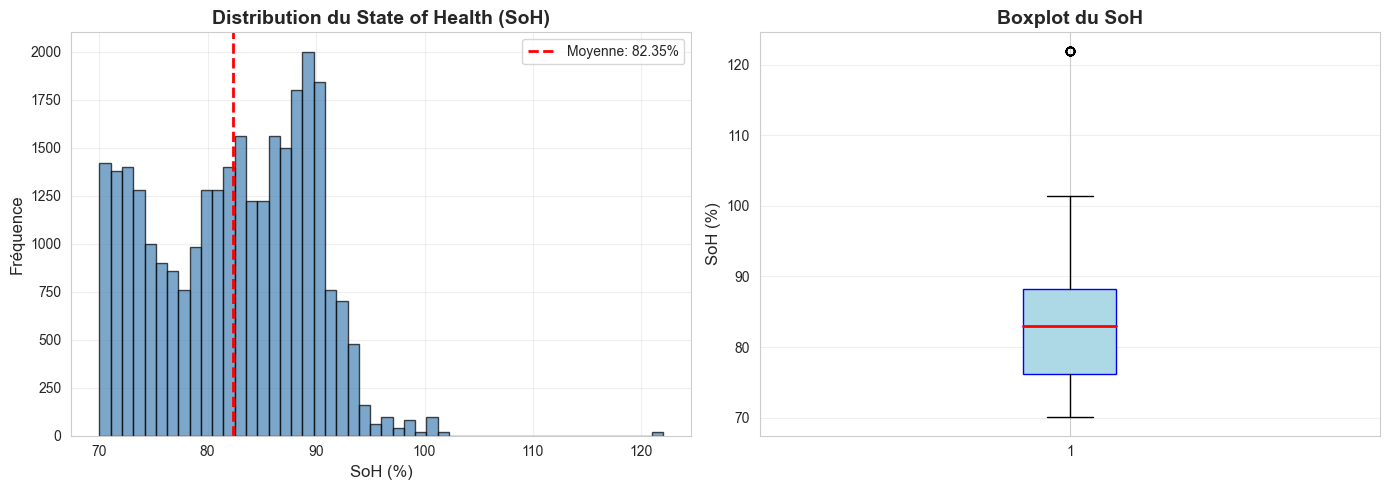


📊 STATISTIQUES DÉTAILLÉES DU SoH (Variable Cible)
   Minimum     : 70.02%
   Maximum     : 122.01%
   Moyenne     : 82.35%
   Médiane     : 82.93%
   Écart-type  : 7.04%
   Étendue     : 51.99%


In [8]:
# ========== ANALYSE DE LA VARIABLE CIBLE : SoH ==========
 
# Création d'une figure avec 2 sous-graphiques côte à côte
# figsize=(14, 5) définit la taille : largeur=14, hauteur=5
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# ========== GRAPHIQUE 1 : HISTOGRAMME ==========
 
# axes[0] = premier graphique (à gauche)
# .hist() crée un histogramme
axes[0].hist(
    df['SoH'],           # Données à afficher
    bins=50,             # Nombre de barres (50 intervalles)
    color='steelblue',   # Couleur des barres
    edgecolor='black',   # Couleur des bordures
    alpha=0.7            # Transparence (0=invisible, 1=opaque)
)
 
# Ajouter une ligne verticale pour la moyenne
# .axvline() trace une ligne verticale
axes[0].axvline(
    df['SoH'].mean(),           # Position : la moyenne du SoH
    color='red',                # Couleur de la ligne
    linestyle='--',             # Style pointillé
    linewidth=2,                # Épaisseur
    label=f'Moyenne: {df["SoH"].mean():.2f}%'  # Légende
)
 
# Personnalisation du graphique
axes[0].set_xlabel('SoH (%)', fontsize=12)  # Label axe X
axes[0].set_ylabel('Fréquence', fontsize=12)  # Label axe Y
axes[0].set_title('Distribution du State of Health (SoH)', 
                   fontsize=14, fontweight='bold')  # Titre
axes[0].legend()  # Afficher la légende
axes[0].grid(True, alpha=0.3)  # Grille légère
 
# ========== GRAPHIQUE 2 : BOXPLOT ==========
 
# axes[1] = deuxième graphique (à droite)
# .boxplot() crée une boîte à moustaches
axes[1].boxplot(
    df['SoH'],                   # Données
    vert=True,                   # Vertical (True) ou horizontal (False)
    patch_artist=True,           # Permet de colorer la boîte
    boxprops=dict(facecolor='lightblue', color='blue'),  # Couleur de la boîte
    medianprops=dict(color='red', linewidth=2)  # Couleur de la médiane
)
 
axes[1].set_ylabel('SoH (%)', fontsize=12)
axes[1].set_title('Boxplot du SoH', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')  # Grille seulement sur l'axe Y
 
# Ajuster l'espacement entre les graphiques
plt.tight_layout()
 
# Afficher les graphiques
plt.show()
 
# ========== STATISTIQUES DU SoH ==========
 
print("\n" + "=" * 70)
print("📊 STATISTIQUES DÉTAILLÉES DU SoH (Variable Cible)")
print("=" * 70)
print(f"   Minimum     : {df['SoH'].min():.2f}%")      # Valeur min
print(f"   Maximum     : {df['SoH'].max():.2f}%")      # Valeur max
print(f"   Moyenne     : {df['SoH'].mean():.2f}%")     # Moyenne
print(f"   Médiane     : {df['SoH'].median():.2f}%")   # Médiane (50e percentile)
print(f"   Écart-type  : {df['SoH'].std():.2f}%")      # Dispersion des données
print(f"   Étendue     : {df['SoH'].max() - df['SoH'].min():.2f}%")  # Max - Min
print("=" * 70)
 

# ## 📊 CELLULE 8 : Distribution des variables d'entrée

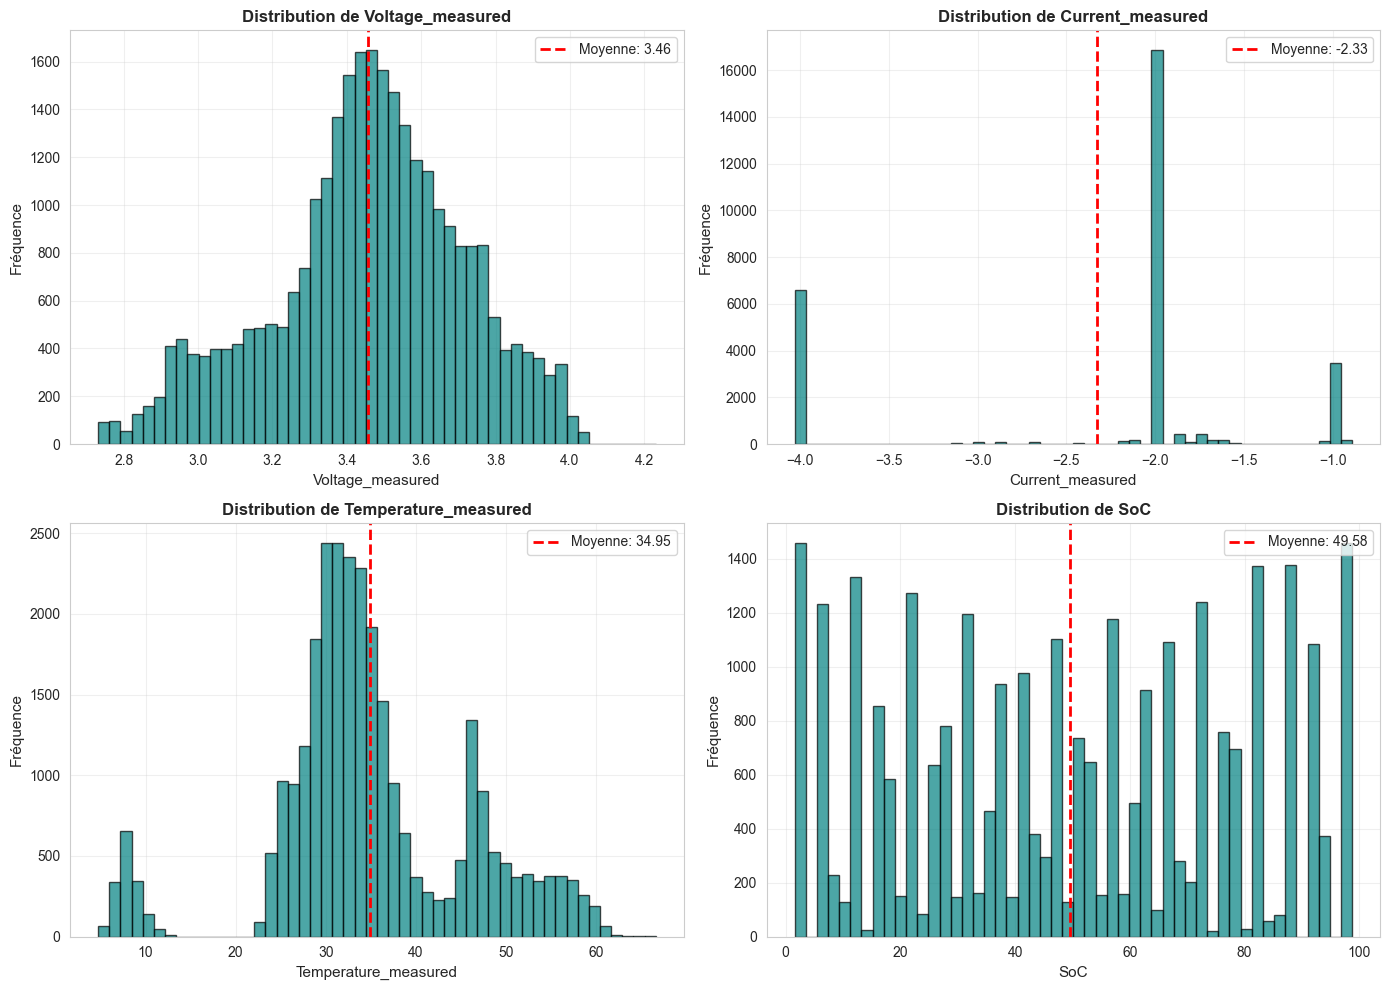

In [9]:
# ========== DISTRIBUTION DES FEATURES PRINCIPALES ==========
 
# Liste des features à analyser (variables d'entrée du futur modèle)
features = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC']
 
# Création d'une grille de 2x2 sous-graphiques
# 2 lignes, 2 colonnes = 4 graphiques au total
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
 
# .ravel() transforme la grille 2D en tableau 1D pour faciliter l'itération
# axes devient [axes[0,0], axes[0,1], axes[1,0], axes[1,1]]
axes = axes.ravel()
 
# Boucle sur chaque feature avec son index
for i, feature in enumerate(features):
    # axes[i] = graphique à la position i
    
    # Créer l'histogramme pour cette feature
    axes[i].hist(
        df[feature],         # Données de cette colonne
        bins=50,             # 50 barres
        color='teal',        # Couleur
        edgecolor='black',   # Bordure noire
        alpha=0.7            # Semi-transparent
    )
    
    # Ajouter une ligne pour la moyenne
    axes[i].axvline(
        df[feature].mean(),  # Position de la ligne
        color='red', 
        linestyle='--', 
        linewidth=2,
        label=f'Moyenne: {df[feature].mean():.2f}'
    )
    
    # Personnalisation
    axes[i].set_xlabel(feature, fontsize=11)
    axes[i].set_ylabel('Fréquence', fontsize=11)
    axes[i].set_title(f'Distribution de {feature}', 
                      fontsize=12, fontweight='bold')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
 
# Ajuster l'espacement
plt.tight_layout()
plt.show()

# ## 🔗 CELLULE 9 : Matrice de corrélation

🔗 ANALYSE DES CORRÉLATIONS



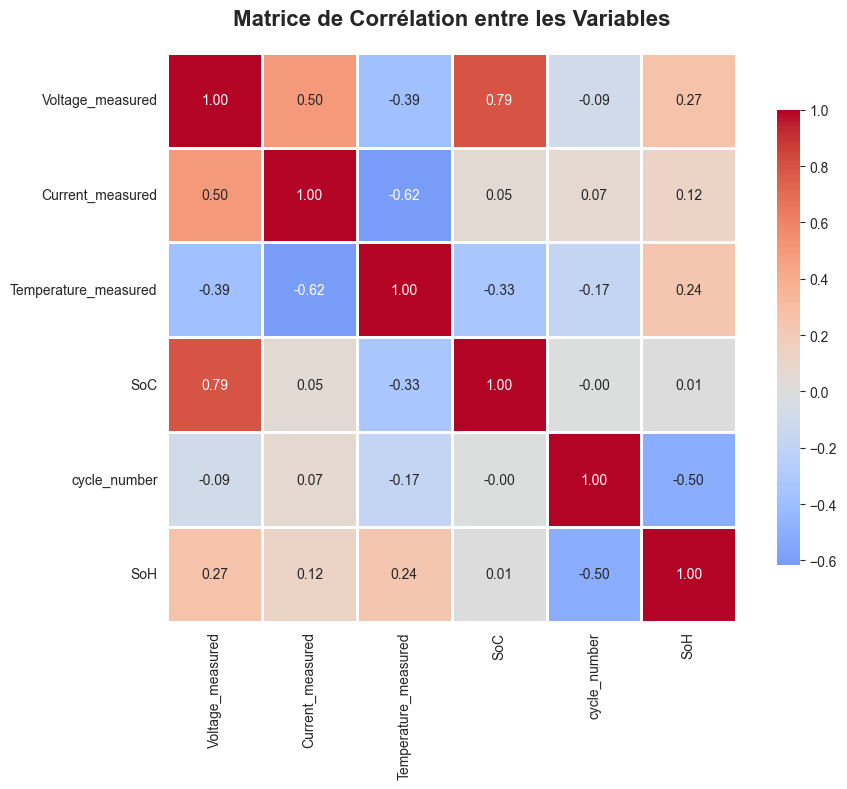


🎯 CORRÉLATIONS AVEC LE SoH (Variable Cible) :

----------------------------------------------------------------------
Voltage_measured          : +0.266  (Faible corrélation positive)
Temperature_measured      : +0.242  (Faible corrélation positive)
Current_measured          : +0.117  (Faible corrélation positive)
SoC                       : +0.005  (Faible corrélation positive)
cycle_number              : -0.505  (Modérée corrélation négative)


In [10]:
# ========== MATRICE DE CORRÉLATION ==========
 
print("=" * 70)
print("🔗 ANALYSE DES CORRÉLATIONS")
print("=" * 70)
print()
 
# Sélection des colonnes numériques pour la corrélation
numerical_cols = [
    'Voltage_measured', 
    'Current_measured', 
    'Temperature_measured', 
    'SoC', 
    'cycle_number', 
    'SoH'
]
 
# Calcul de la matrice de corrélation
# .corr() calcule le coefficient de corrélation de Pearson entre chaque paire de variables
# Valeurs entre -1 et 1 :
#   -1 = corrélation négative parfaite
#    0 = pas de corrélation
#   +1 = corrélation positive parfaite
correlation_matrix = df[numerical_cols].corr()
 
# ========== VISUALISATION AVEC HEATMAP ==========
 
# Taille de la figure
plt.figure(figsize=(10, 8))
 
# sns.heatmap() crée une carte de chaleur
sns.heatmap(
    correlation_matrix,      # Matrice à afficher
    annot=True,              # Afficher les valeurs dans les cases
    fmt='.2f',               # Format : 2 décimales
    cmap='coolwarm',         # Palette de couleurs (bleu=négatif, rouge=positif)
    center=0,                # Centrer la palette sur 0
    square=True,             # Cases carrées
    linewidths=1,            # Largeur des lignes entre cases
    cbar_kws={"shrink": 0.8} # Taille de la barre de couleur
)
 
# Titre
plt.title('Matrice de Corrélation entre les Variables', 
          fontsize=16, fontweight='bold', pad=20)
 
plt.tight_layout()
plt.show()
 
# ========== CORRÉLATIONS AVEC LE SoH ==========
 
print("\n🎯 CORRÉLATIONS AVEC LE SoH (Variable Cible) :\n")
print("-" * 70)
 
# Extraire la colonne SoH de la matrice
# .sort_values() trie du plus fort au plus faible
soh_corr = correlation_matrix['SoH'].sort_values(ascending=False)
 
# Afficher avec interprétation
for var, corr in soh_corr.items():
    if var == 'SoH':
        continue  # Ne pas afficher SoH vs SoH (toujours 1.0)
    
    # Interprétation de la corrélation
    if abs(corr) > 0.7:
        strength = "Forte"
    elif abs(corr) > 0.4:
        strength = "Modérée"
    else:
        strength = "Faible"
    
    direction = "positive" if corr > 0 else "négative"
    
    print(f"{var:25} : {corr:+.3f}  ({strength} corrélation {direction})")
 
print("=" * 70)

# ## 📉 CELLULE 10 : Évolution du SoH par batterie

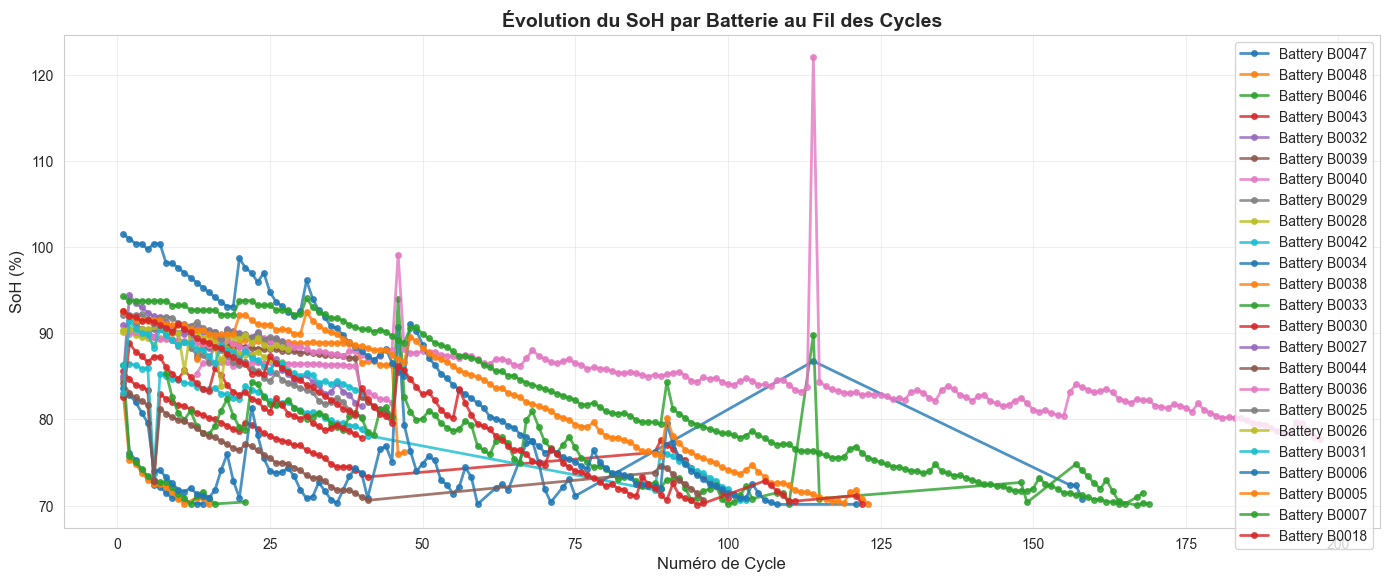


✅ Observation : Le SoH diminue progressivement avec les cycles
   → C'est la dégradation naturelle des batteries au fil du temps


In [11]:
# ========== ÉVOLUTION DU SoH AU FIL DES CYCLES ==========
 
# Taille de la figure
plt.figure(figsize=(14, 6))
 
# Boucle sur chaque batterie
for battery in df['battery_id'].unique():
    # Filtrer les données pour cette batterie uniquement
    # df[df['battery_id'] == battery] crée un sous-DataFrame
    battery_data = df[df['battery_id'] == battery]
    
    # Calculer le SoH moyen par cycle
    # (car il y a plusieurs mesures par cycle)
    # .groupby('cycle_number') groupe par numéro de cycle
    # ['SoH'].mean() calcule la moyenne du SoH pour chaque groupe
    cycle_soh = battery_data.groupby('cycle_number')['SoH'].mean()
    
    # Tracer la courbe pour cette batterie
    # cycle_soh.index = numéros de cycles
    # cycle_soh.values = valeurs de SoH moyennes
    plt.plot(
        cycle_soh.index,         # Axe X : numéros de cycles
        cycle_soh.values,        # Axe Y : SoH
        marker='o',              # Marqueurs ronds à chaque point
        markersize=4,            # Taille des marqueurs
        label=f'Battery {battery}',  # Légende
        linewidth=2,             # Épaisseur de la ligne
        alpha=0.8                # Transparence
    )
 
# Personnalisation du graphique
plt.xlabel('Numéro de Cycle', fontsize=12)
plt.ylabel('SoH (%)', fontsize=12)
plt.title('Évolution du SoH par Batterie au Fil des Cycles', 
          fontsize=14, fontweight='bold')
plt.legend(loc='best')  # Placer la légende au meilleur endroit
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 
print("\n✅ Observation : Le SoH diminue progressivement avec les cycles")
print("   → C'est la dégradation naturelle des batteries au fil du temps")
print("=" * 70)
 
 

# ## 📊 CELLULE 11 : Voltage vs SoC (Courbes de décharge)

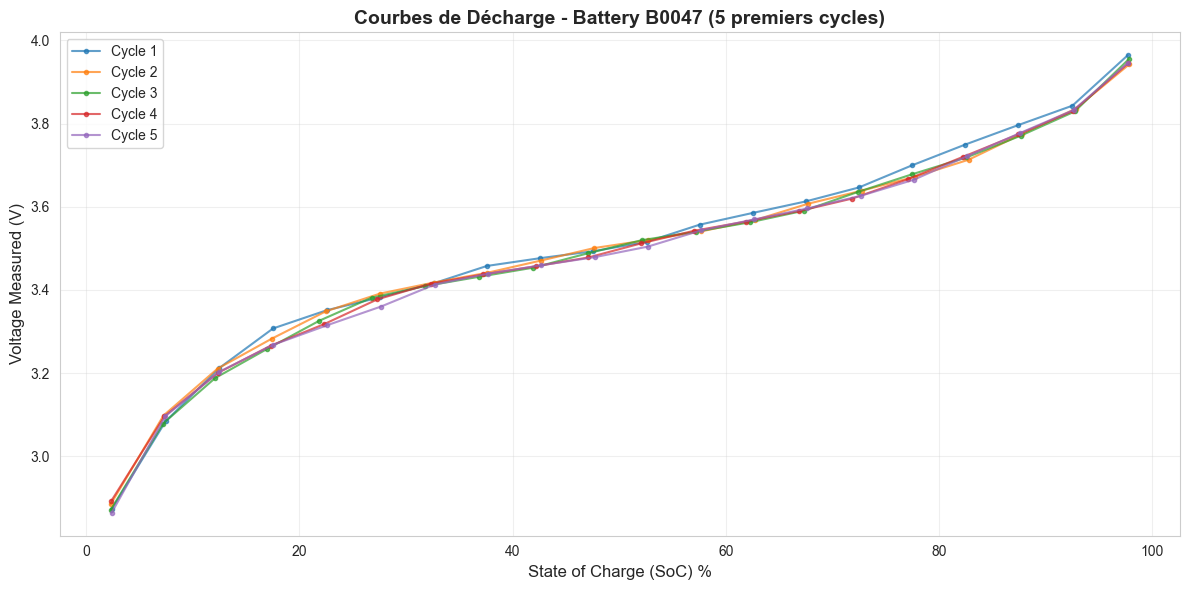


✅ Observation : Le voltage diminue quand le SoC diminue
   → C'est la courbe de décharge caractéristique d'une batterie


In [12]:
# ========== RELATION VOLTAGE vs SoC ==========
 
# Prendre la première batterie comme exemple
first_battery = df['battery_id'].unique()[0]
battery_data = df[df['battery_id'] == first_battery]
 
# Prendre les 5 premiers cycles
cycles_to_plot = battery_data['cycle_number'].unique()[:5]
 
# Créer le graphique
plt.figure(figsize=(12, 6))
 
# Boucle sur chaque cycle
for cycle in cycles_to_plot:
    # Filtrer les données de ce cycle
    cycle_data = battery_data[battery_data['cycle_number'] == cycle]
    
    # Trier par SoC pour avoir une courbe continue
    cycle_data = cycle_data.sort_values('SoC')
    
    # Tracer Voltage en fonction de SoC
    plt.plot(
        cycle_data['SoC'],              # Axe X : State of Charge
        cycle_data['Voltage_measured'], # Axe Y : Voltage
        marker='o',                     # Marqueurs ronds
        markersize=3,                   # Taille
        label=f'Cycle {cycle}',         # Légende
        alpha=0.7                       # Transparence
    )
 
# Personnalisation
plt.xlabel('State of Charge (SoC) %', fontsize=12)
plt.ylabel('Voltage Measured (V)', fontsize=12)
plt.title(f'Courbes de Décharge - Battery {first_battery} (5 premiers cycles)', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 
print("\n✅ Observation : Le voltage diminue quand le SoC diminue")
print("   → C'est la courbe de décharge caractéristique d'une batterie")
print("=" * 70)
 
 

# ## 📊 CELLULE 12 : Scatter plots (Relations avec SoH)

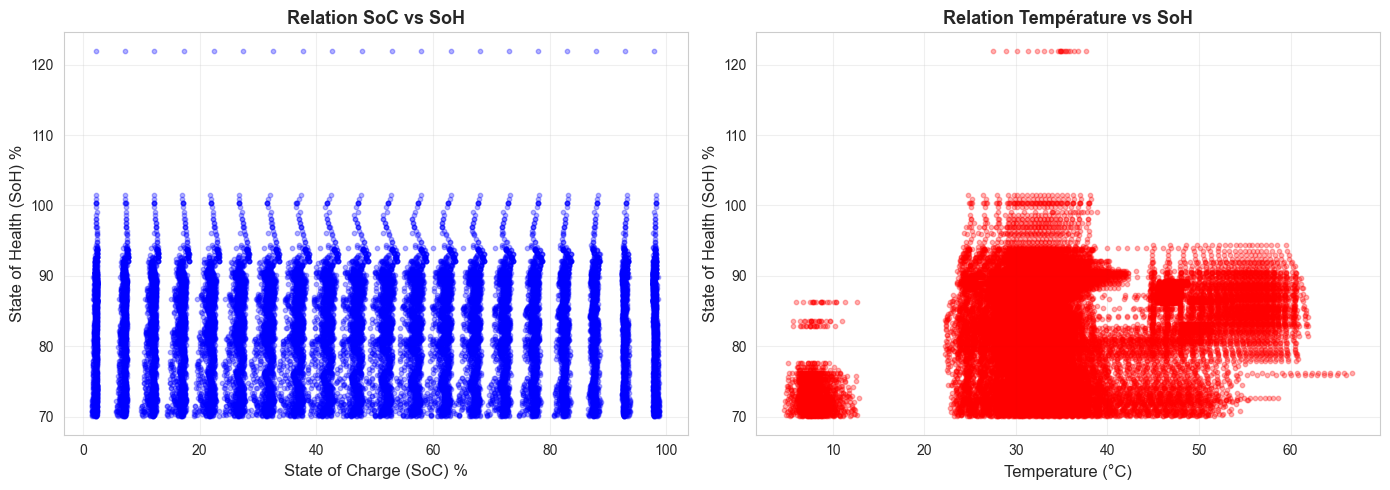


💡 Interprétation des scatter plots :
   - Si les points forment une ligne → corrélation forte
   - Si les points sont dispersés → corrélation faible


In [13]:
# ========== SCATTER PLOTS : RECHERCHE DE RELATIONS ==========
 
# Créer 2 graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# ========== GRAPHIQUE 1 : SoC vs SoH ==========
 
# .scatter() crée un nuage de points
axes[0].scatter(
    df['SoC'],      # Axe X
    df['SoH'],      # Axe Y
    alpha=0.3,      # Transparence (pour voir les superpositions)
    s=10,           # Taille des points
    color='blue'    # Couleur
)
 
axes[0].set_xlabel('State of Charge (SoC) %', fontsize=12)
axes[0].set_ylabel('State of Health (SoH) %', fontsize=12)
axes[0].set_title('Relation SoC vs SoH', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
 
# ========== GRAPHIQUE 2 : Température vs SoH ==========
 
axes[1].scatter(
    df['Temperature_measured'],  # Axe X
    df['SoH'],                   # Axe Y
    alpha=0.3, 
    s=10, 
    color='red'
)
 
axes[1].set_xlabel('Temperature (°C)', fontsize=12)
axes[1].set_ylabel('State of Health (SoH) %', fontsize=12)
axes[1].set_title('Relation Température vs SoH', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()
 
print("\n💡 Interprétation des scatter plots :")
print("   - Si les points forment une ligne → corrélation forte")
print("   - Si les points sont dispersés → corrélation faible")
print("=" * 70)
 

# ## 📊 CELLULE 13 : Boxplots par batterie

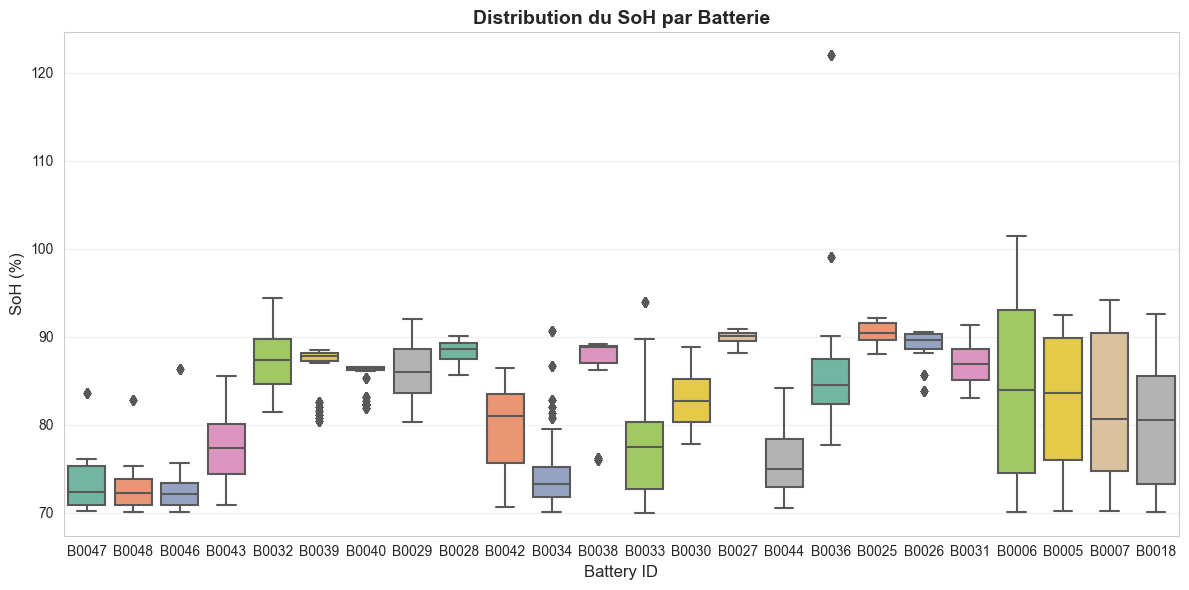


💡 Ce graphique montre :
   - La médiane du SoH pour chaque batterie (ligne au milieu de la boîte)
   - La dispersion des valeurs (hauteur de la boîte)
   - Les valeurs extrêmes (points isolés)


In [15]:
# ========== DISTRIBUTION DU SoH PAR BATTERIE ==========
 
# Créer le graphique
plt.figure(figsize=(12, 6))
 
# Créer un boxplot pour chaque batterie
# data=df : source des données
# x='battery_id' : variable catégorielle (axe X)
# y='SoH' : variable numérique (axe Y)
# palette='Set2' : palette de couleurs
sns.boxplot(data=df, x='battery_id', y='SoH', palette='Set2')
 
# Personnalisation
plt.xlabel('Battery ID', fontsize=12)
plt.ylabel('SoH (%)', fontsize=12)
plt.title('Distribution du SoH par Batterie', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
 
print("\n💡 Ce graphique montre :")
print("   - La médiane du SoH pour chaque batterie (ligne au milieu de la boîte)")
print("   - La dispersion des valeurs (hauteur de la boîte)")
print("   - Les valeurs extrêmes (points isolés)")
print("=" * 70)
 

# ## 🎯 CELLULE 14 : Résumé de l'exploration

In [16]:
# ========== RÉSUMÉ COMPLET DE L'EXPLORATION ==========
 
print("\n")
print("=" * 80)
print("                   📊 RÉSUMÉ DE L'EXPLORATION DES DONNÉES")
print("=" * 80)
 
# Informations générales
print(f"\n✅ Dataset chargé       : {df.shape[0]:,} mesures, {df.shape[1]} variables")
print(f"✅ Batteries analysées  : {df['battery_id'].nunique()}")
print(f"✅ Cycles totaux        : {df['cycle_number'].max()}")
print(f"✅ Valeurs manquantes   : {df.isnull().sum().sum()} (0 = données complètes)")
 
# Statistiques de la variable cible
print(f"\n📈 VARIABLE CIBLE (SoH) :")
print(f"   - Plage     : [{df['SoH'].min():.2f}% - {df['SoH'].max():.2f}%]")
print(f"   - Moyenne   : {df['SoH'].mean():.2f}%")
print(f"   - Médiane   : {df['SoH'].median():.2f}%")
print(f"   - Écart-type: {df['SoH'].std():.2f}%")
 
# Variables d'entrée
print(f"\n📊 VARIABLES D'ENTRÉE (Features) :")
for col in ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC']:
    print(f"   - {col:25} : [{df[col].min():.2f} - {df[col].max():.2f}]")
 
# Observations importantes
print(f"\n🔍 OBSERVATIONS CLÉS :")
print("   ✓ Le SoH diminue progressivement avec les cycles → Dégradation attendue")
print("   ✓ Corrélations visibles entre Voltage, SoC et SoH")
print("   ✓ Données propres : pas de valeurs manquantes")
print("   ✓ Plusieurs mesures par cycle → Permettra de créer des fenêtres glissantes")
print("   ✓ Les batteries ont des profils de dégradation différents")
 
# Prochaines étapes
print(f"\n🎯 PROCHAINES ÉTAPES :")
print("   1️⃣  Normaliser les données (MinMaxScaler)")
print("   2️⃣  Créer des fenêtres glissantes (ex: 5 bins consécutifs)")
print("   3️⃣  Split train/validation/test")
print("   4️⃣  Construire le modèle LSTM")
print("   5️⃣  Entraîner et évaluer")
 
print("=" * 80)
print("✅ EXPLORATION TERMINÉE ! Prêt pour le preprocessing.")
print("=" * 80)
print("\n")
 
 



                   📊 RÉSUMÉ DE L'EXPLORATION DES DONNÉES

✅ Dataset chargé       : 29,180 mesures, 7 variables
✅ Batteries analysées  : 24
✅ Cycles totaux        : 197
✅ Valeurs manquantes   : 0 (0 = données complètes)

📈 VARIABLE CIBLE (SoH) :
   - Plage     : [70.02% - 122.01%]
   - Moyenne   : 82.35%
   - Médiane   : 82.93%
   - Écart-type: 7.04%

📊 VARIABLES D'ENTRÉE (Features) :
   - Voltage_measured          : [2.73 - 4.23]
   - Current_measured          : [-4.03 - -0.89]
   - Temperature_measured      : [4.72 - 66.67]
   - SoC                       : [1.54 - 98.76]

🔍 OBSERVATIONS CLÉS :
   ✓ Le SoH diminue progressivement avec les cycles → Dégradation attendue
   ✓ Corrélations visibles entre Voltage, SoC et SoH
   ✓ Données propres : pas de valeurs manquantes
   ✓ Plusieurs mesures par cycle → Permettra de créer des fenêtres glissantes
   ✓ Les batteries ont des profils de dégradation différents

🎯 PROCHAINES ÉTAPES :
   1️⃣  Normaliser les données (MinMaxScaler)
   2️⃣  Cré

# ## 💾 CELLULE 15 : Sauvegarde des insights 

In [17]:
# ========== SAUVEGARDE DES STATISTIQUES CLÉS ==========
 
# Créer un dictionnaire avec les infos importantes
exploration_summary = {
    'n_samples': len(df),
    'n_features': len(df.columns),
    'n_batteries': df['battery_id'].nunique(),
    'n_cycles': df['cycle_number'].max(),
    'soh_min': df['SoH'].min(),
    'soh_max': df['SoH'].max(),
    'soh_mean': df['SoH'].mean(),
    'soh_std': df['SoH'].std(),
    'missing_values': df.isnull().sum().sum()
}
 
# Afficher le résumé
print("📊 Résumé sauvegardé :")
for key, value in exploration_summary.items():
    print(f"   {key:20} : {value}")
 
# (Optionnel) Sauvegarder dans un fichier JSON
# import json
# with open('../results/metrics/exploration_summary.json', 'w') as f:
#     json.dump(exploration_summary, f, indent=4)
 
print("\n✅ Fin du notebook d'exploration !")
 

📊 Résumé sauvegardé :
   n_samples            : 29180
   n_features           : 7
   n_batteries          : 24
   n_cycles             : 197
   soh_min              : 70.02223613488894
   soh_max              : 122.01162842295211
   soh_mean             : 82.34763952301803
   soh_std              : 7.040966150701574
   missing_values       : 0

✅ Fin du notebook d'exploration !
